In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import h5py
import pandas as pd
from pathlib import Path
import hdf5view

# CIV mock Absorbers
f1 = h5py.File('spectra_TNG50-1_z1.5_n1000d2-fullbox_DESI_CIV_combined.hdf5')
f2 = h5py.File('spectra_TNG50-1_z2.0_n1000d2-fullbox_DESI_CIV_combined.hdf5')
f3 = h5py.File('spectra_TNG50-1_z3.0_n1000d2-fullbox_DESI_CIV_combined.hdf5')
f4 = h5py.File('spectra_TNG50-1_z4.0_n1000d2-fullbox_DESI_CIV_combined.hdf5')
f5 = h5py.File('spectra_TNG50-1_z5.0_n1000d2-fullbox_DESI_CIV_combined.hdf5')

In [ ]:
# unpack files
#print(list(f1.keys()))
flux_CIV_1 = f1['flux']
wave_CIV_1 = f1['wave']
tau_1548_1 = f1['tau_CIV_1548']
tau_1550_1 = f1['tau_CIV_1550']
EW_CIV_1548_1 = f1['EW_CIV_1548']
EW_CIV_1550_1 = f1['EW_CIV_1550']

flux_CIV_2 = f2['flux']
wave_CIV_2 = f2['wave']
tau_1548_2 = f2['tau_CIV_1548']
tau_1550_2 = f2['tau_CIV_1550']
EW_CIV_1548_2 = f2['EW_CIV_1548']
EW_CIV_1550_2 = f2['EW_CIV_1550']

flux_CIV_3 = f3['flux']
wave_CIV_3 = f3['wave']
tau_1548_3 = f3['tau_CIV_1548']
tau_1550_3 = f3['tau_CIV_1550']
EW_CIV_1548_3 = f3['EW_CIV_1548']
EW_CIV_1550_3 = f3['EW_CIV_1550']

flux_CIV_4 = f4['flux']
wave_CIV_4 = f4['wave']
tau_1548_4 = f4['tau_CIV_1548']
tau_1550_4 = f4['tau_CIV_1550']
EW_CIV_1548_4 = f4['EW_CIV_1548']
EW_CIV_1550_4 = f4['EW_CIV_1550']

flux_CIV_5 = f5['flux']
wave_CIV_5 = f5['wave']
tau_1548_5 = f5['tau_CIV_1548']
tau_1550_5 = f5['tau_CIV_1550']
EW_CIV_1548_5 = f5['EW_CIV_1548']
EW_CIV_1550_5 = f5['EW_CIV_1550']

In [26]:
! hdf5view -f 'spectra_TNG50-1_z1.5_n1000d2-fullbox_DESI_CIV_combined.hdf5'

Traceback (most recent call last):
  File "/opt/anaconda3/envs/desi-env/bin/hdf5view", line 5, in <module>
    from hdf5view.main import main
  File "/opt/anaconda3/envs/desi-env/lib/python3.10/site-packages/hdf5view/main.py", line 12, in <module>
    import qtpy
  File "/opt/anaconda3/envs/desi-env/lib/python3.10/site-packages/qtpy/__init__.py", line 293, in <module>
    raise QtBindingsNotFoundError from None
qtpy.QtBindingsNotFoundError: No Qt bindings could be found


In [ ]:
print(list(f1.keys()))
print(hdf5view.show(f1))
print(min(wave_CIV_1), max(wave_CIV_1))
print(np.size(wave_CIV_1))
print(np.shape(flux_CIV_1))

['EW_CIV_1548', 'EW_CIV_1550', 'flux', 'ray_dir', 'ray_pos', 'ray_total_dl', 'tau_CIV_1548', 'tau_CIV_1550', 'wave']
3600.4 9823.6
7780
(1000000, 7780)


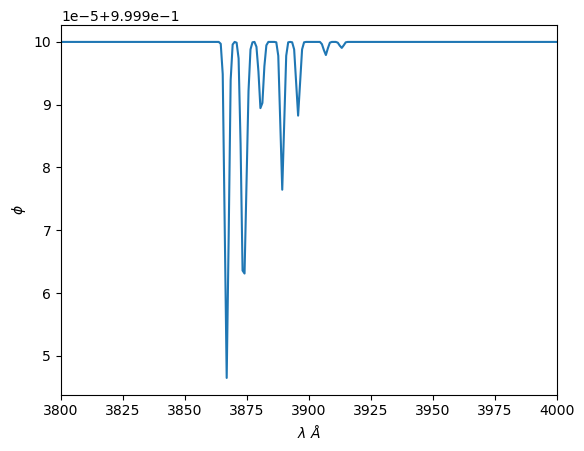

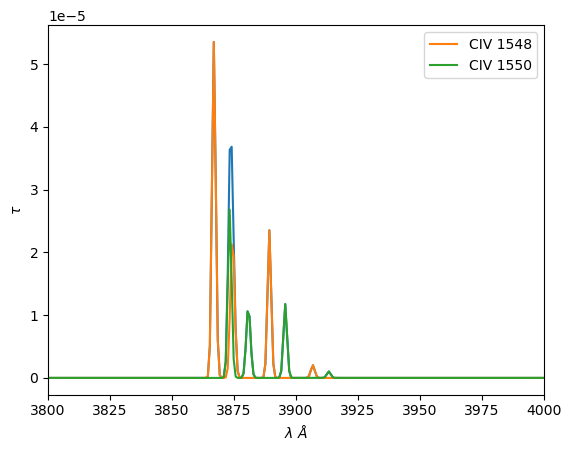

In [47]:
i = 279 # abs index
flux_array = np.array(flux_CIV_1[i])
wave_array = np.array(wave_CIV_1)
tau_1548_array = np.array(tau_1548_1[i])
tau_1550_array = np.array(tau_1550_1[i])
tau_tot = tau_1548_array + tau_1550_array # Total Optical Depth
plt.figure(1)
plt.plot(wave_array, flux_array) # CIV Flux Plot
plt.xlabel('$\lambda\ {\AA}$')
plt.ylabel('$\phi$')
plt.xlim(3800,4000)

plt.figure(2)
plt.plot(wave_array, tau_tot); # CIV Optical Depth Plot
plt.plot(wave_array, tau_1548_array, label='CIV 1548')
plt.plot(wave_array, tau_1550_array, label='CIV 1550')
plt.xlabel('$\lambda\ {\AA}$')
plt.ylabel('$\\tau$')
plt.xlim(3800,4000)
plt.legend()


In [37]:
print(tau_1548_1.shape)
print(len(flux_CIV_1))
print(wave_CIV_1.shape)

(1000000, 7780)
1000000
(7780,)


In [16]:
# make folder
outdir = Path("mock_absorbers")      # name of your folder
outdir.mkdir(exist_ok=True)

In [ ]:
#wave15 = np.array([])
#tau15 = np.array([])
max_tau15 = []
z_abs15 = []
id15 = []
EW15_1550 = []
EW15_1548 = []

n_spectra = len(flux_CIV_1)                    
indices = np.random.choice(np.arange(n_spectra), size=1000000, replace=False)
i = 0 # index for good absorbers
k = 0 # index to run loop 1000 iterations
while i<1000:
    j = indices[k]
    k += 1
    wave_i = np.array(wave_CIV_1)
    tau_i = np.array(tau_1548_1[j]) + np.array(tau_1550_1[j])
    max_tau_i = np.max(tau_i)
    if max_tau_i <= 0:
        continue

    EW15_1550.append(EW_CIV_1550_1[j])
    EW15_1548.append(EW_CIV_1548_1[j])

    hdu_primary = fits.PrimaryHDU(tau_i.astype(np.float32))
    hdul = fits.HDUList([hdu_primary])
    outname = outdir / f"15{i:04d}.fits"
    hdul.writeto(outname, overwrite=True)

    name = f"15{i:04d}"
    id15.append(name)

    #wave15.append(wave_i)
    #tau15.append(tau_i)
    max_tau15.append(max_tau_i)
    

    ind_1550 = int(np.argmax(np.array(tau_1550_1[j])))
    lambda_1550 = wave_i[ind_1550]
    z_abs15.append((lambda_1550 - 1550.77001953125) / 1550.77001953125) #need to replace 1550
    i += 1
max_tau15 = np.array(max_tau15)
z_abs15 = np.array(z_abs15)
id15 = np.array(id15)
EW15_1550 = np.array(EW15_1550)
EW15_1548 = np.array(EW15_1548)


In [ ]:
#wave20 = np.array([])
#tau20 = np.array([])
max_tau20 = []
z_abs20 = []
id20 = []
EW20_1550 = []
EW20_1548 = []

n_spectra = len(flux_CIV_2)                    
indices = np.random.choice(np.arange(n_spectra), size=1000000, replace=False)
i = 0
k = 0
while i<1000:
    j = indices[k]
    k += 1
    wave_i = np.array(wave_CIV_2)
    tau_i = np.array(tau_1548_2[j]) + np.array(tau_1550_2[j])
    max_tau_i = np.max(tau_i)
    if max_tau_i <= 0:
        continue

    EW20_1550.append(EW_CIV_1550_2[j])
    EW20_1548.append(EW_CIV_1548_2[j])

    hdu_primary = fits.PrimaryHDU(tau_i.astype(np.float32))
    hdul = fits.HDUList([hdu_primary])
    outname = outdir / f"20{i:04d}.fits"
    hdul.writeto(outname, overwrite=True)

    name = f"20{i:04d}"
    id20.append(name)

    #wave20.append(wave_i)
    #tau20.append(tau_i)
    max_tau20.append(max_tau_i)
    

    ind_1550 = int(np.argmax(np.array(tau_1550_2[j])))
    lambda_1550 = wave_i[ind_1550]
    z_abs20.append((lambda_1550 - 1550.77001953125) / 1550.77001953125) #need to replace 1550
    i += 1
max_tau20 = np.array(max_tau20)
z_abs20 = np.array(z_abs20)
id20 = np.array(id20)
EW20_1550 = np.array(EW20_1550)
EW20_1548 = np.array(EW20_1548)

In [ ]:
#wave30 = np.array([])
#tau30 = np.array([])
max_tau30 = []
z_abs30 = []
id30 = []
EW30_1550 = []
EW30_1548 = []

n_spectra = len(flux_CIV_3)                    
indices = np.random.choice(np.arange(n_spectra), size=1000000, replace=False)
i = 0
k = 0
while i<1000:
    j = indices[k]
    k += 1
    wave_i = np.array(wave_CIV_3)
    tau_i = np.array(tau_1548_3[j]) + np.array(tau_1550_3[j])
    max_tau_i = np.max(tau_i)
    if max_tau_i <= 0:
        continue

    EW30_1550.append(EW_CIV_1550_3[j])
    EW30_1548.append(EW_CIV_1548_3[j])

    hdu_primary = fits.PrimaryHDU(tau_i.astype(np.float32))
    hdul = fits.HDUList([hdu_primary])
    outname = outdir / f"30{i:04d}.fits"
    hdul.writeto(outname, overwrite=True)

    name = f"30{i:04d}"
    id30.append(name)

    #wave30.append(wave_i)
    #tau30.append(tau_i)
    max_tau30.append(max_tau_i)


    ind_1550 = int(np.argmax(np.array(tau_1550_3[j])))
    lambda_1550 = wave_i[ind_1550]
    z_abs30.append((lambda_1550 - 1550.77001953125) / 1550.77001953125) #need to replace 1550
    i += 1
max_tau30 = np.array(max_tau30)
z_abs30 = np.array(z_abs30)
id30 = np.array(id30)
EW30_1550 = np.array(EW30_1550)
EW30_1548 = np.array(EW30_1548)

#wave40 = np.array([])
#tau40 = np.array([])
max_tau40 = []
z_abs40 = []
id40 = []
EW40_1550 = []
EW40_1548 = []

n_spectra = len(flux_CIV_4)                    
indices = np.random.choice(np.arange(n_spectra), size=1000000, replace=False)
i = 0
k = 0
while i<1000:
    j = indices[k]
    k += 1
    wave_i = np.array(wave_CIV_4)
    tau_i = np.array(tau_1548_4[j]) + np.array(tau_1550_4[j])
    max_tau_i = np.max(tau_i)
    if max_tau_i <= 0:
        continue

    EW40_1550.append(EW_CIV_1550_4[j])
    EW40_1548.append(EW_CIV_1548_4[j])

    hdu_primary = fits.PrimaryHDU(tau_i.astype(np.float32))
    hdul = fits.HDUList([hdu_primary])
    outname = outdir / f"40{i:04d}.fits"
    hdul.writeto(outname, overwrite=True)

    name = f"40{i:04d}"
    id40.append(name)

    #wave40.append(wave_i)
    #tau40.append(tau_i)
    max_tau40.append(max_tau_i)

    ind_1550 = int(np.argmax(np.array(tau_1550_4[j])))
    lambda_1550 = wave_i[ind_1550]
    z_abs40.append((lambda_1550 - 1550.77001953125) / 1550.77001953125) #need to replace 1550
    i += 1
max_tau40 = np.array(max_tau40)
z_abs40 = np.array(z_abs40)
id40 = np.array(id40)
EW40_1550 = np.array(EW40_1550)
EW40_1548 = np.array(EW40_1548)

#wave50 = np.array([])
#tau50 = np.array([])
max_tau50 = []
z_abs50 = []
id50 = []
EW50_1550 = []
EW50_1548 = []

n_spectra = len(flux_CIV_5)                    
indices = np.random.choice(np.arange(n_spectra), size=1000000, replace=False)
i = 0
k = 0
while i<1000:
    j = indices[k]
    k += 1
    wave_i = np.array(wave_CIV_5)
    tau_i = np.array(tau_1548_5[j]) + np.array(tau_1550_5[j])
    max_tau_i = np.max(tau_i)
    if max_tau_i <= 0:
        continue

    EW50_1550.append(EW_CIV_1550_5[j])
    EW50_1548.append(EW_CIV_1548_5[j])

    hdu_primary = fits.PrimaryHDU(tau_i.astype(np.float32))
    hdul = fits.HDUList([hdu_primary])
    outname = outdir / f"50{i:04d}.fits"
    hdul.writeto(outname, overwrite=True)

    name = f"50{i:04d}"
    id50.append(name)

    #wave50.append(wave_i)
    #tau50.append(tau_i)
    max_tau50.append(max_tau_i)


    ind_1550 = int(np.argmax(np.array(tau_1550_5[j])))
    lambda_1550 = wave_i[ind_1550]
    z_abs50.append((lambda_1550 - 1550.77001953125) / 1550.77001953125) #need to replace 1550
    i += 1
max_tau50 = np.array(max_tau50)
z_abs50 = np.array(z_abs50)
id50 = np.array(id50)
EW50_1550 = np.array(EW50_1550)
EW50_1548 = np.array(EW50_1548)

In [ ]:
max_tau = np.concatenate([max_tau15, max_tau20,max_tau30,max_tau40,max_tau50])
z_abs = np.concatenate([z_abs15, z_abs20,z_abs30,z_abs40,z_abs50])
id = np.concatenate([id15, id20,id30,id40,id50])
EW_1550 = np.concatenate([EW15_1550, EW20_1550,EW30_1550,EW40_1550,EW50_1550])
EW_1548 = np.concatenate([EW15_1548, EW20_1548,EW30_1548,EW40_1548,EW50_1548])

cols = fits.ColDefs([
    fits.Column(name='ID',       format='10A', array=id),
    fits.Column(name='MAX_TAU',  format='E',   array=max_tau),
    fits.Column(name='Z_ABS',    format='E',   array=z_abs),
    fits.Column(name='EW_1550',  format='E',   array=EW_1550),
    fits.Column(name='EW_1548',  format='E',   array=EW_1548),
])
hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto("mock_absorbers_answerkey.fits", overwrite=True)


(array([1000.,    0.,    0.,    0., 1000.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,  898.,  102.,    0.,    0.,    0.,    0.,
           0.,    0.,  118.,  882.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 1000.]),
 array([1.49574194, 1.61574422, 1.7357465 , 1.85574878, 1.97575106,
        2.09575334, 2.21575563, 2.33575791, 2.45576019, 2.57576247,
        2.69576475, 2.81576704, 2.93576932, 3.0557716 , 3.17577388,
        3.29577616, 3.41577845, 3.53578073, 3.65578301, 3.77578529,
        3.89578757, 4.01578985, 4.13579214, 4.25579442, 4.3757967 ,
        4.49579898, 4.61580126, 4.73580355, 4.85580583, 4.97580811,
        5.09581039]),
 <BarContainer object of 30 artists>)

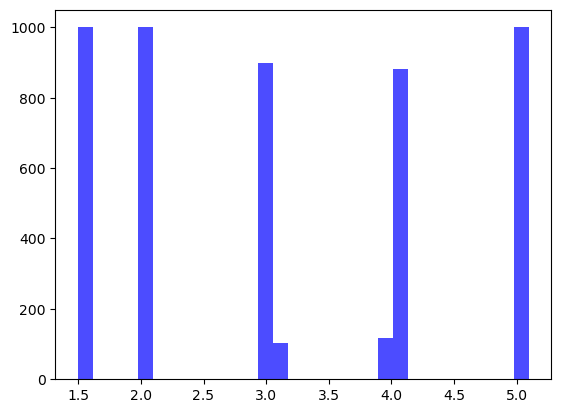

In [21]:
#histogram of z_abs values
plt.figure(3)
plt.hist(np.array(z_abs), bins=30, alpha=0.7, color='blue',)

(2000,)
(2000, 7780)


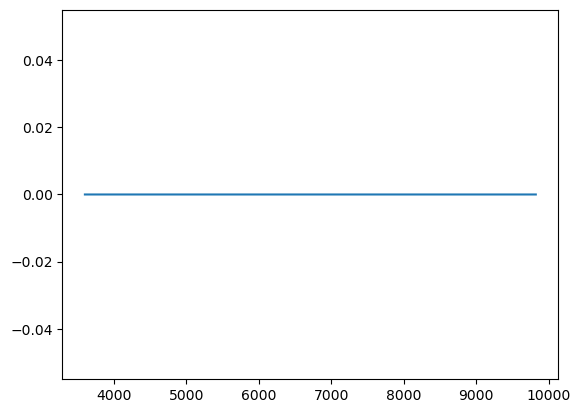

In [65]:
print(np.shape(z_abs2))
print(np.shape(tau2))

ind = (np.array(z_abs2) < 1.4)
tau2_14 = np.array(tau2)[ind]

#plt.figure(1)
plt.plot(wave2[1], tau2_14[1]) # CIV Flux Plot
#plt.xlabel('$\lambda\ {\AA}$')
#plt.ylabel('$\Tau$')
#plt.xlim(3800,4000)

In [ ]:
max_depth = [];
ind_array = [];
for j in range(1000):
    tau_2796_array = np.array(tau_2796[j])
    tau_2803_array = np.array(tau_2803[j])
    tau_tot = tau_2796_array + tau_2803_array
    tau_max = np.max(tau_tot)
    if tau_max > 0:
        max_depth.append(tau_max)
        ind_array.append(j)

In [ ]:
plt.figure(3)
plt.hist(np.log10(max_depth), bins=20);
plt.xlabel('$\log(\\tau_{max})$');

In [ ]:
data = {'index': ind_array, 'log(tau_max)': max_depth}
df = pd.DataFrame(data)
df.to_csv('MgII_max_depths_test.csv', index=False)